# Weather Temperature Predictions - OLS Regression

A **multiple linear regression model** is a statistical method that describes the linear relationship between a continuous target (Dependent/ Y variable) and two or more features (Independent/ X variables), determining how much each feature contributes to the outcome. 

---

### Define the Problem
Can Temperature be accurately predicted knowing the Dew Point Temperature, Relative Humidity %, Wind Speed km/h, Visibility km, and/ or Pressure kPa?


**The dataset** aims to predict the Temperature based on the Dew Point Temperature, Relative Humidity %, Wind Speed km/h, Visibility km, and/ or Pressure kPa. This dataset is found on kaggle - https://www.kaggle.com/code/esraameslamsayed/eda-for-weather-dataset-for-beginners/log? It does not state any descriptive factors about where this data is from or when it was captured. The only descriptive feature is that Temperature and Dew Point Temperature is measured in degrees celsius.

**Features:**
- Dew Point Temp_C
- Rel Hum_%
- Wind Speed_km/h
- Visibility_km
- Press_kPa	

**Target:**
- Temperature

---

### Summary of Findings

This notebook builds an interpretable baseline for temperature (Temp_C) using OLS regression. Wind Speed and Visibility are removed during preprocessing — Wind Speed shows no linear relationship with temperature, and Visibility is non-predictive for this analysis. An initial OLS using standardized features (Dew Point Temp_C, Rel Hum_%, and Press_kPa) yields R² = 0.995, with all three features statistically significant (p < 0.001) and a Durbin–Watson statistic of 2.017, indicating no autocorrelation.

Multicollinearity is assessed via VIF: all features score below 1.17 (Dew Point = 1.129, Rel Hum = 1.059, Press_kPa = 1.165), confirming no problematic collinearity. Normality of residuals is evaluated via histogram and Shapiro–Wilk test; while normality is rejected (p < 0.001), the large sample size (n = 6,952 training observations) ensures valid inference via the Central Limit Theorem. Heteroscedasticity is detected using the Breusch–Pagan test (p < 0.001), so HC3 robust standard errors are applied to correct statistical inference.

The final model retains all three features. Evaluated on an 80/20 train–test split, it achieves R² = 0.995 on both sets, RMSE = 0.801°C and MAE = 0.603°C on the test set, with minimal overfitting (R² difference of 0.0001).

---

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

---
## 1. Data Loading & Initial Analysis

In [2]:
raw_data = pd.read_csv('../data/weather_data.csv')

data = raw_data.copy()
data = data.reset_index(drop=True)

print('First few rows:')
print('='*80)
display(data.head())

print('Summary Statistics:')
print('='*80)
display(data.describe(include='all'))

print('Dataset Information:')
print('='*80)
data.info()

First few rows:


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


Summary Statistics:


,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784
unique,8784,NaN,NaN,NaN,NaN,NaN,NaN,50
top,1/1/2012 0:00,NaN,NaN,NaN,NaN,NaN,NaN,Mainly Clear
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,2106
mean,NaN,8.798144,2.555294,67.431694,14.945469,27.664447,101.051623,NaN
std,NaN,11.687883,10.883072,16.918881,8.688696,12.622688,0.844005,NaN
min,NaN,-23.300000,-28.500000,18.000000,0.000000,0.200000,97.520000,NaN
25%,NaN,0.100000,-5.900000,56.000000,9.000000,24.100000,100.560000,NaN
50%,NaN,9.300000,3.300000,68.000000,13.000000,25.000000,101.070000,NaN
75%,NaN,18.800000,11.800000,81.000000,20.000000,25.000000,101.590000,NaN


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date/Time         8784 non-null   object 
 1   Temp_C            8784 non-null   float64
 2   Dew Point Temp_C  8784 non-null   float64
 3   Rel Hum_%         8784 non-null   int64  
 4   Wind Speed_km/h   8784 non-null   int64  
 5   Visibility_km     8784 non-null   float64
 6   Press_kPa         8784 non-null   float64
 7   Weather           8784 non-null   object 
dtypes: float64(4), int64(2), object(2)
memory usage: 549.1+ KB


---
## 2. Preprocessing 
### a. Exploratory Data Analysis with Visuals
#### i.	Histograms for Normality

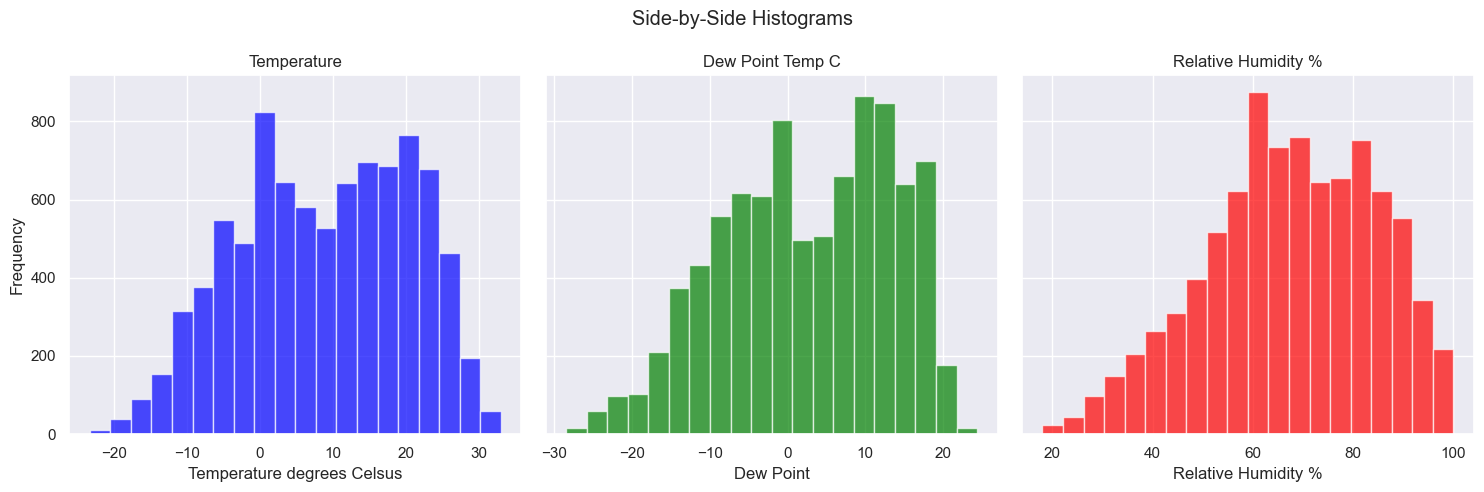

In [3]:
# Check for normal distribution of data
temperature = data['Temp_C']
dew_point = data['Dew Point Temp_C']
rel_humidity = data['Rel Hum_%']

# Create a 1x3 grid of subplots
# sharey=True to use the same y-axis scale
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)  

# Plot each histogram on a separate subplot
axes[0].hist(temperature, bins = 20, color='blue', alpha=0.7)
axes[0].set_title('Temperature')
axes[0].set_xlabel('Temperature degrees Celsus')
axes[0].set_ylabel('Frequency')

axes[1].hist(dew_point, bins = 20, color='green', alpha=0.7)
axes[1].set_title('Dew Point Temp C')
axes[1].set_xlabel('Dew Point')

axes[2].hist(rel_humidity, bins = 20, color='red', alpha=0.7)
axes[2].set_title('Relative Humidity %')
axes[2].set_xlabel('Relative Humidity %')


# Add a main title
fig.suptitle('Side-by-Side Histograms')

# Display the plot
plt.tight_layout()
plt.show()

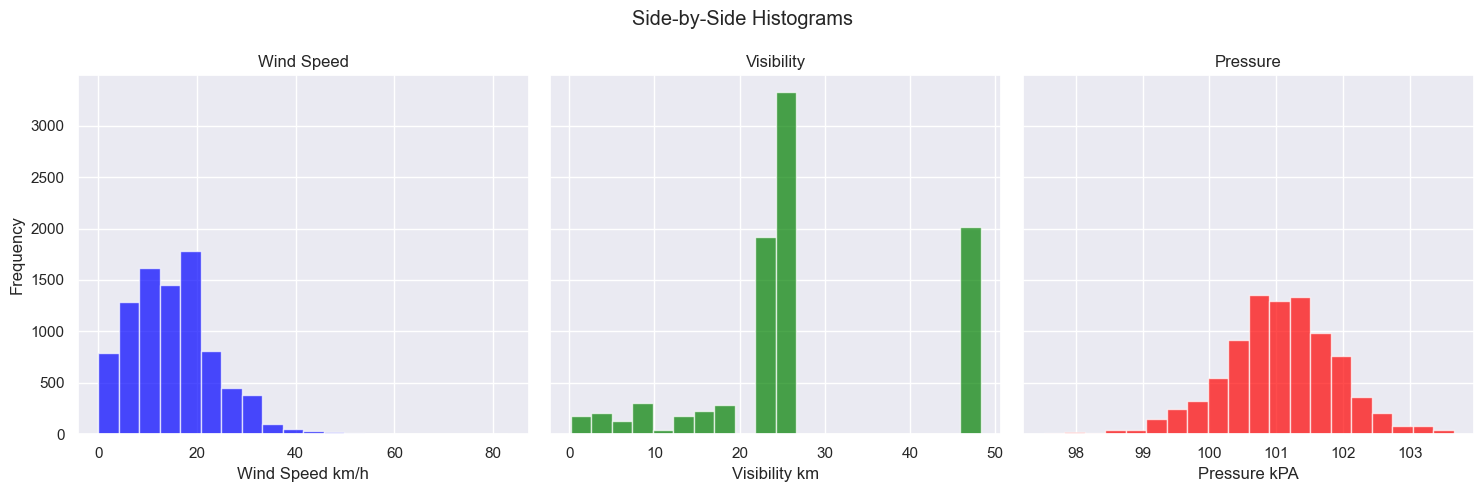

In [4]:
wind_speed = data['Wind Speed_km/h']
visibility = data['Visibility_km']
pressure = data['Press_kPa']

# Create a 1x3 grid of subplots
# sharey=True to use the same y-axis scale
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)  

# Plot each histogram on a separate subplot
axes[0].hist(wind_speed, bins=20, color='blue', alpha=0.7)
axes[0].set_title('Wind Speed')
axes[0].set_xlabel('Wind Speed km/h')
axes[0].set_ylabel('Frequency')

axes[1].hist(visibility, bins=20, color='green', alpha=0.7)
axes[1].set_title('Visibility')
axes[1].set_xlabel('Visibility km')

axes[2].hist(pressure, bins=20, color='red', alpha=0.7)
axes[2].set_title('Pressure')
axes[2].set_xlabel('Pressure kPA')

# Add a main title
fig.suptitle('Side-by-Side Histograms')

# Display the plot
plt.tight_layout()
plt.show()

>**Findings:**
>- Most variables appear to be normally distributed except for Wind Speed and Visibility. Visibility will be removed and so will the outliers from Wind Speed.

##### 1. Remove Visibility

In [5]:
# Dropping Visibility and other unnecessary columns 
normal_data = data.drop(['Visibility_km','Date/Time','Weather'],axis=1)

##### 2. Remove Outliers

<Axes: xlabel='Wind Speed_km/h', ylabel='Count'>

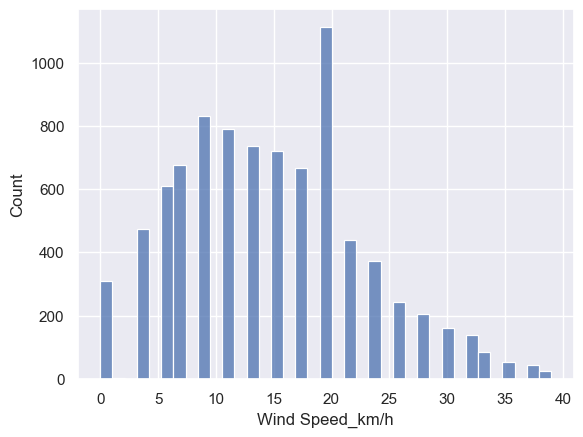

In [6]:
# Declare q as a variable that will be equal to the 99th percentile of the 'Wind Speed_km/h' variable
# DataFrame.quantile(the quantile)
q = normal_data['Wind Speed_km/h'].quantile(0.99)
# Create a new df, with the condition that all Wind Speeds must be below the 99 percentile of 'Wind Speed_km/h'
data_1 = normal_data[normal_data['Wind Speed_km/h']<q]
# The top 1% of the data about 'Wind Speed_km/h' has been removed
data_1.describe(include='all')
data_cleaned = data_1.reset_index(drop=True)
sns.histplot(data_cleaned['Wind Speed_km/h'])

#### ii. Linearity with Scatter Plot

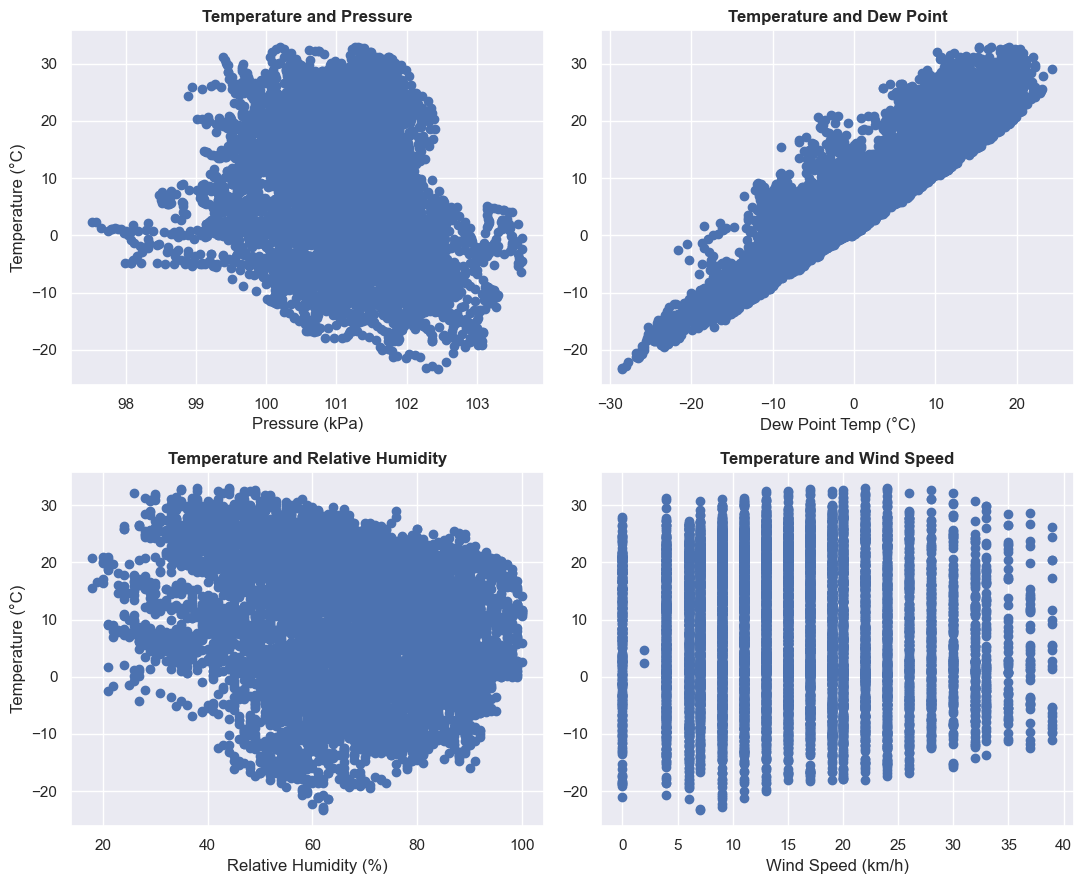

In [7]:
# Create 2x2 subplot layout
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

# Plot 1: Pressure vs Temperature
axes[0].scatter(data_cleaned['Press_kPa'], data_cleaned['Temp_C'])
axes[0].set_title('Temperature and Pressure', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Pressure (kPa)')
axes[0].set_ylabel('Temperature (°C)')

# Plot 2: Dew Point vs Temperature
axes[1].scatter(data_cleaned['Dew Point Temp_C'], data_cleaned['Temp_C'])
axes[1].set_title('Temperature and Dew Point', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dew Point Temp (°C)')

# Plot 3: Humidity vs Temperature
axes[2].scatter(data_cleaned['Rel Hum_%'], data_cleaned['Temp_C'])
axes[2].set_title('Temperature and Relative Humidity', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Relative Humidity (%)')
axes[2].set_ylabel('Temperature (°C)')

# Plot 4: Wind Speed vs Temperature
axes[3].scatter(data_cleaned['Wind Speed_km/h'], data_cleaned['Temp_C'])
axes[3].set_title('Temperature and Wind Speed', fontsize=12, fontweight='bold')
axes[3].set_xlabel('Wind Speed (km/h)')

plt.tight_layout()
plt.show()

>**Findings**
>- Dew Point shows the most linear relationship while wind speed shows none and will be removed. 
>- Relative Humidity and Pressure show a slight negative relationship and will be kept for now

##### 1. Remove Wind Speed

In [8]:
data_cleaned = data_cleaned.drop(['Wind Speed_km/h'],axis=1)

---
## 3. Model Development
### a. Train Test Split

In [9]:
# Declare features and target
features = [
    'Dew Point Temp_C', 
    'Rel Hum_%',
    'Press_kPa']

X = data_cleaned[features]
y = data_cleaned['Temp_C']

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=365)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame with original column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=features, index=X_test.index)

### b. Check Assumptions
#### i. Check for Endogeneity & Autocorrelation with Statsmodels
Endogeneity
- Check variables to make sure their p-value <= 0.05 — if it is larger, the feature needs to be removed.

Autocorrelation
- The correlation of a variable with itself over successive time intervals
- Use the Durbin–Watson test (0–4): 2 indicates no autocorrelation, while values below 1 and above 3 are cause for alarm

In [10]:
# Fit model with statsmodel
X_train_scaled_const = sm.add_constant(X_train_scaled)
model = sm.OLS(y_train, X_train_scaled_const).fit()
display(model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Temp_C   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 4.689e+05
Date:                Wed, 18 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:10:09   Log-Likelihood:                -8513.0
No. Observations:                6952   AIC:                         1.703e+04
Df Residuals:                    6948   BIC:                         1.706e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                8.7787      0.010    888.766      0.000       8.759       8.798
Dew Point Temp_C    11.5307      0.010   1098.850      0.000      11.510      11.551
Rel Hum_%           -4.2106      0.010   -414.262      0.000      -4.231      -4.191
Press_kPa           -0.0592      0.011     -5.550      0.000      -0.080      -0.038
==============================================================================
Omnibus:                     3036.006   Durbin-Watson:                   2.017
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            18970.520
Skew:                           1.999   Prob(JB):                         0.00
Kurtosis:                      10.036   Cond. No.                         1.50
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

>**Findings of Initial Model Assessment:**
>- R-squared: 0.995 - Strong explanatory power
>- Prob (F-statistic): 0.00 - Model is statistically significant
>- All features have a p-value < 0.05
>- Durbin-Watson: 2.017 - no autocorrelation

#### ii. Check for Multicollinearity with VIF
Multicollinearity is observed when two or more variables have a high correlation.
- VIF = 1: no multicollinearity
- 1 < VIF < 5: perfectly okay
- 5 to 10 < VIF: unacceptable

In [11]:
# Create a new data frame which will include all the VIFs
vif = pd.DataFrame()
# make use of the variance_inflation_factor, which will basically output the respective VIFs 
vif["VIF"] = [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
# include names so it is easier to explore the result
vif["Features"] = X_train_scaled.columns
vif

,VIF,Features
0,1.128626,Dew Point Temp_C
1,1.058909,Rel Hum_%
2,1.164640,Press_kPa


>**Findings**
>- All features are well below 5 and closer to 1 so no multicollinearity.

#### iii. Normality of Residuals - Histogram & Shapiro-Wilk Test

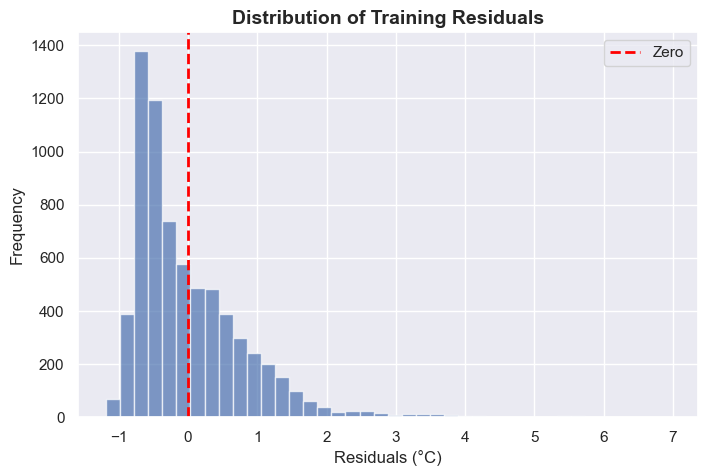

Shapiro-Wilk Test: p-value = 2.3508e-64
Residuals show some deviation from normality
  Sample size: n = 6,952 → CLT applies


In [12]:
# Get residuals
residuals = model.resid

# Create histogram
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=40, density=False, alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
plt.title('Distribution of Training Residuals', fontsize=14, fontweight='bold')
plt.xlabel('Residuals (°C)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# Normality test
shapiro_stat, shapiro_p = shapiro(residuals)
print(f"Shapiro-Wilk Test: p-value = {shapiro_p:.4e}")

if shapiro_p > 0.05:
    print("Residuals appear normally distributed (bell curve)")
else:
    print("Residuals show some deviation from normality")
    print(f"  Sample size: n = {len(residuals):,} → CLT applies")

>**Test Results:**
>- Shapiro-Wilk: p < 0.001 (rejects normality)
>- Visual: Histogram shows right-skew
>
>**Interpretation:**
>Residuals are not perfectly normal, they exhibit right-skew and heavier-than-normal right tail. However, this does not compromise model validity for two reasons:
>1. **Large Sample Size (n = 6,295):** Central Limit Theorem ensures coefficient estimates and hypothesis tests remain valid despite non-normality
>2. **Physical Explanation:** The right tail represents underprediction of some warm temperatures, suggesting non-linear relationships or missing variables at temperature extremes
>
>**Conclusion:** While normality assumption is violated, the large sample size ensures robust inference. This is acceptable for the model's purpose.

#### iv. Homoscedasticity - Scatter Plots
- Homoscedasticity - Residuals should roughly be centered around 0 with no clear pattern, this indicates the model errors are random, a good sign for linear regression assumptions.
    - If points are randomly scattered → good, homoscedastic.
    - If residuals fan out or form a pattern → heteroscedasticity.

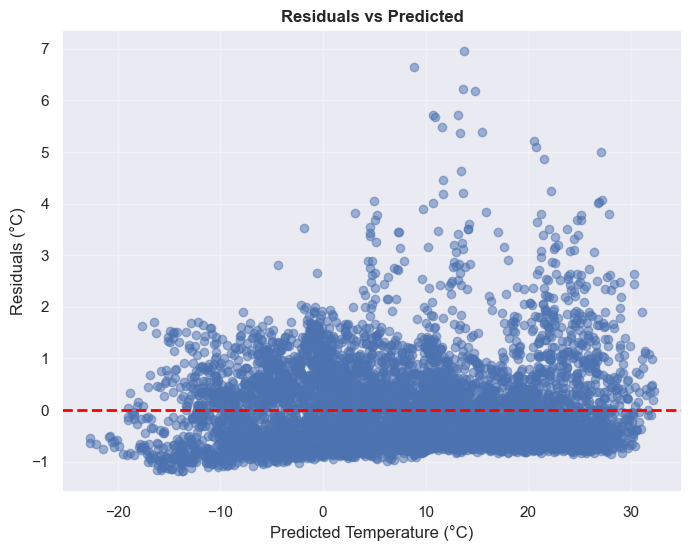

In [13]:
# Get predictions
predictions = model.fittedvalues

# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Predicted Temperature (°C)')
plt.ylabel('Residuals (°C)')
plt.title('Residuals vs Predicted', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# Breusch–Pagan test for homoscedasticity
exog = model.model.exog
bp_test = het_breuschpagan(residuals, exog)
labels = ["LM Stat", "LM-Test p-value", "F-Stat", "F-Test p-value"]
print(dict(zip(labels, bp_test)))

{'LM Stat': 661.8589071010108, 'LM-Test p-value': 3.9096860734215923e-143, 'F-Stat': 243.69329816407623, 'F-Test p-value': 2.342631710267379e-150}


>**Findings:**
> 
>**Visual Analysis:** Residuals vs Predicted: Illustrates a fanned out variance across the predicted value.
> 
>**Breusch-Pagan Test Result:** p < 0.001 (heteroscedasticity detected)
> 
>**Implication:** OLS standard errors are biased when variance is non-constant, making p-values and confidence intervals unreliable.
> 
>**Solution:** Used heteroscedasticity-consistent standard errors (HC3) to correct statistical inference. While heteroscedasticity remains in the model, the robust standard errors ensure valid hypothesis tests and confidence intervals.
>
>**Result:** All features remain highly significant even with corrected standard errors, confirming the robustness of our findings.

#### v. Assumption Validation Summary

| Assumption | Test Used | Result | Status |
|---|---|---|---|
| Feature Significance (No Endogeneity) | OLS p-values | All features p < 0.001 | Pass |
| No Autocorrelation | Durbin–Watson | 2.017 | Pass |
| No Multicollinearity | VIF | Max VIF = 1.165 (all below 5) | Pass |
| Normality of Residuals | Shapiro–Wilk | p < 0.001 — normality rejected | Acceptable: large sample, CLT applies |
| Homoscedasticity | Breusch–Pagan | p < 0.001 — heteroscedasticity detected | Corrected: HC3 robust standard errors applied |

---
## 4. Model Evaluation

In [15]:
# Fit model with robust standard errors
X_train_const = sm.add_constant(X_train_scaled)
model_final = sm.OLS(y_train, X_train_const).fit(cov_type='HC3')

# Get predictions for test set
X_test_const = sm.add_constant(X_test_scaled)
y_pred_test = model_final.predict(X_test_const)
residuals_test = y_test - y_pred_test

# Calculate all metrics
train_r2 = model_final.rsquared
train_rmse = np.sqrt(mean_squared_error(y_train, model_final.fittedvalues))
train_mae = mean_absolute_error(y_train, model_final.fittedvalues)

test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_mae = mean_absolute_error(y_test, y_pred_test)

# Create summary table
evaluation_summary = pd.DataFrame({
    'Training Set': [train_r2, train_rmse, train_mae],
    'Testing Set': [test_r2, test_rmse, test_mae]
}, index=['R²', 'RMSE', 'MAE'])

print("Model Evaluation Summary:")
print()
display(evaluation_summary.style.format("{:.3f}"))

print("\nOverfitting Check:")
print(f"  R² Difference:   {abs(train_r2 - test_r2):.4f}")
print(f"  RMSE Difference: {abs(train_rmse - test_rmse):.4f} °C")
print(f"  MAE Increase:    {abs(test_mae - train_mae):.4f}°C")

print("\n" + "-"*70)
if abs(train_r2 - test_r2) < 0.01:
    print("Minimal overfitting - model generalizes well")
elif abs(train_r2 - test_r2) < 0.05:
    print("Slight overfitting - Model performs reasonably on unseen data")
else:
    print("Signigicant overfitting - Model may not generalize well")


Model Evaluation Summary:



,Training Set,Testing Set
R²,0.995,0.995
RMSE,0.823,0.801
MAE,0.619,0.603



Overfitting Check:
  R² Difference:   0.0001
  RMSE Difference: 0.0220 °C
  MAE Increase:    0.0164°C

----------------------------------------------------------------------
Minimal overfitting - model generalizes well


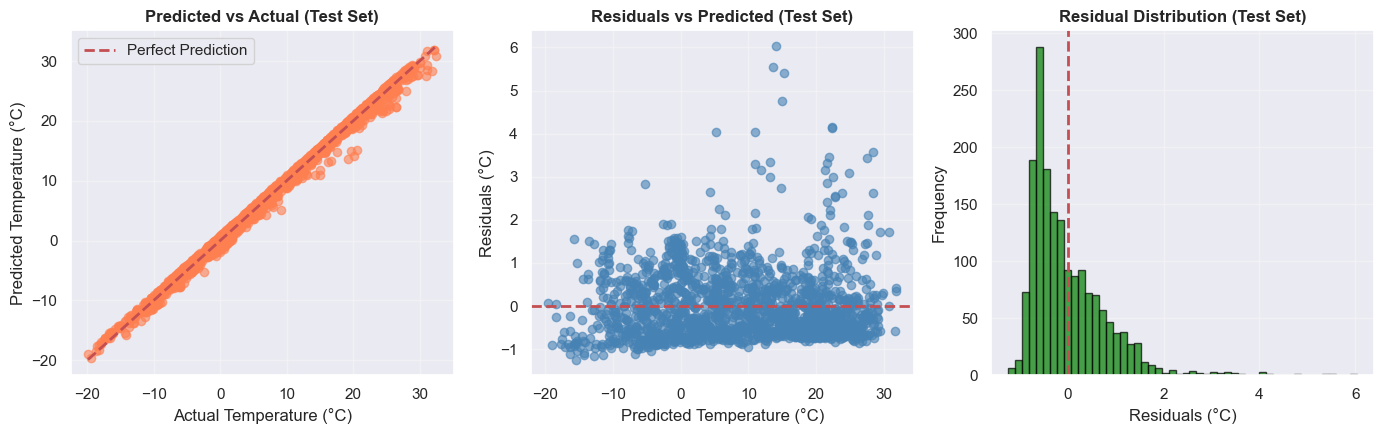

In [16]:
# Visualize test set performance
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred_test, alpha=0.6, color='coral')
axes[0].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 
             'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Predicted vs Actual (Test Set)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Actual Temperature (°C)')
axes[0].set_ylabel('Predicted Temperature (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Residuals vs Predicted
axes[1].scatter(y_pred_test, residuals_test, alpha=0.6, color='steelblue')
axes[1].axhline(0, color='r', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted (Test Set)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Temperature (°C)')
axes[1].set_ylabel('Residuals (°C)')
axes[1].grid(True, alpha=0.3)

# Residual Distribution
axes[2].hist(residuals_test, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].axvline(0, color='r', linestyle='--', linewidth=2)
axes[2].set_title('Residual Distribution (Test Set)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Residuals (°C)')
axes[2].set_ylabel('Frequency')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

,Feature,Coefficient,p-value
0,Dew Point Temp_C,11.5307,0.0000e+00
1,Rel Hum_%,-4.2106,0.0000e+00
2,Press_kPa,-0.0592,2.4120e-09


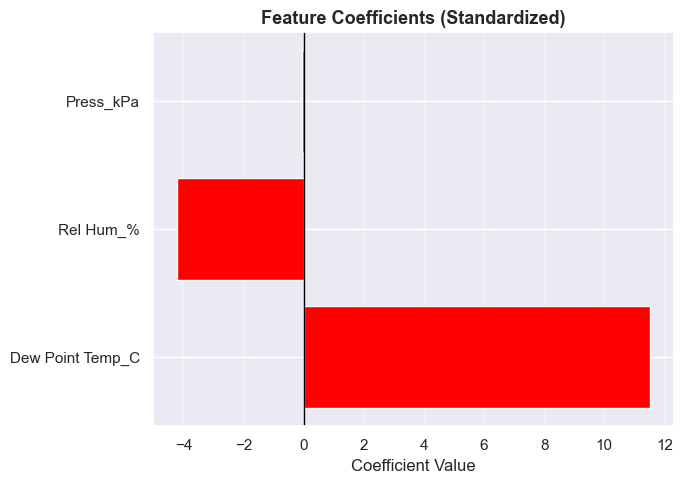

In [17]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Coefficient': model_final.params[1:].values,
    'Std Error': model_final.bse[1:].values,
    'p-value': model_final.pvalues[1:].values,
    '|Coefficient|': np.abs(model_final.params[1:].values)
}).sort_values('|Coefficient|', ascending=False)

display(feature_importance[['Feature', 'Coefficient', 'p-value']].style.format({
    'Coefficient': '{:.4f}',
    'p-value': '{:.4e}'
}))

# Visualize coefficients
plt.figure(figsize=(7, 5))
plt.barh(feature_importance['Feature'], feature_importance['Coefficient'], 
         color=['red' if p < 0.001 else 'orange' for p in feature_importance['p-value']])
plt.xlabel('Coefficient Value', fontsize=12)
plt.title('Feature Coefficients (Standardized)', fontsize=13, fontweight='bold')
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


>**Findings**
>- **Dew Point Temp_C** is the dominant predictor (+11.5307), driving the majority of the model's predictive power
>- **Rel Hum_%** shows a moderate negative influence (−4.2106), while **Press_kPa** contributes minimally (−0.0592)
>- All three features are highly significant (p < 0.001)

---
## Conclusion
**Can Temperature be accurately predicted knowing the Dew Point Temperature, Relative Humidity %, and Pressure kPa?**

Yes. The final model demonstrates that temperature can be predicted with a high degree of accuracy using just three features: 
Dew Point Temperature, Relative Humidity, and Pressure. With an R² of 0.995, the model explains 99.5% of the variance 
in temperature, and a test MAE of 0.603°C confirms that typical predictions are within less than 1°C of the actual value.

From the original five features, Visibility was excluded as non-predictive and Wind Speed showed no meaningful linear relationship with temperature and was also removed. The remaining three features were sufficient to build a highly accurate and well-generalising model.

### Model Performance

**Final Model:** Temperature ~ Dew Point Temperature + Relative Humidity + Pressure (features standardized)

| Metric | Training Set | Test Set | Interpretation |
|---|---|---|---|
| R² | 0.995 | 0.995 | The model explains 99.5% of variance in temperature |
| RMSE (°C) | 0.823 | 0.801 | Predictions are within ~0.8°C of actual temperature on average |
| MAE (°C) | 0.619 | 0.603 | Typical prediction error is just over 0.6°C |

The near-identical train and test scores (R² difference of 0.0001) confirm the model generalizes well with no meaningful overfitting.

**R²** (R-Squared) measures the proportion of variance in the target variable explained by the model. 
A value of 1.0 is a perfect fit, the closer to 1.0, the better the model captures the underlying patterns in the data.

**RMSE** (Root Mean Squared Error) measures the average magnitude of prediction errors in the same units as the target. 
It penalises large errors more heavily than small ones, making it useful for identifying when the model produces occasional large mispredictions.

**MAE** (Mean Absolute Error) measures the average absolute difference between predicted and actual values, also in the target's units. 
Unlike RMSE, all errors are weighted equally, giving a straightforward view of typical prediction error.

Together, these three metrics provide a balanced evaluation, R² explains how well the model fits the data overall, 
while RMSE and MAE quantify the practical size of prediction errors in real-world terms. If the model is mostly accurate but occasionally very wrong, RMSE will be noticeably higher than MAE. When they are close together, it means errors are consistent and the model isn't making any particularly bad predictions.

### Model Equation

**Temp_C = 8.7787 + 11.5307(Dew Point Temp_C\*) − 4.2106(Rel Hum_%\*) − 0.0592(Press_kPa\*)**

> **Note:** All features are standardized (zero mean, unit variance) prior to fitting. Coefficients reflect scaled units and are directly comparable — Dew Point Temperature is by far the dominant predictor, with an influence roughly 2.7× greater than Relative Humidity and ~195× greater than Pressure.

### Key Findings

1. **Dew Point Temperature** is the dominant predictor, with the largest standardized coefficient (+11.531), reflecting the strong physical relationship between dew point and air temperature.

2. **Relative Humidity** has a strong negative association (standardized coefficient = −4.211), indicating that higher humidity correlates with lower temperatures in this dataset.

3. **Pressure** contributes a small but statistically significant negative effect (standardized coefficient = −0.059), and all three features remain significant under HC3 robust standard errors.

4. **No multicollinearity** — all VIF scores are below 1.17, well within acceptable range.

5. **Heteroscedasticity** was detected and addressed with HC3 robust standard errors, ensuring valid inference despite non-constant residual variance.

6. **Normality** is technically violated (Shapiro–Wilk p < 0.001), but the large sample size means coefficient estimates and hypothesis tests remain valid via the Central Limit Theorem.

### Limitations

- The dataset lacks geographic and temporal metadata, limiting interpretability and generalizability
- Heteroscedasticity is present in the model — robust standard errors correct inference but do not eliminate the underlying variance issue
- The model shows increased dispersion at higher predicted temperatures, suggesting non-linear dynamics at extremes
- A linear model may not fully capture the complexity of temperature behavior across all conditions
- Normality of residuals is violated; robust inference depends on the large sample size assumption

### Next Steps

1. **Address heteroscedasticity directly** — apply weighted least squares (WLS), a log-transform on the target, or explore robust regression methods

2. **Feature engineering** — add seasonal and temporal features (month, hour, season), create interaction terms (e.g. humidity × dew point), and consider lagged temperature values for a time-series approach

3. **Alternative models** — experiment with polynomial regression to capture non-linearity, tree-based methods such as Random Forest or XGBoost, or an LSTM for time-series prediction

4. **Robust cross-validation** — apply k-fold CV for more reliable performance estimates and test on separate time periods to assess temporal generalizability